<font color='blue'>  **2b _______________ One-Dimensional Steady Conduction with External Convection and Dirichlet  BC___** </font> 
<font color='green'> **2c ____  and Neumann .. insulated surface. ___** </font> 

In [1]:
from Grid import Grid  ; from BoundaryConditions import BoundaryLocation, DirichletBc, NeumannBc        ;from ScalarCoeffs import ScalarCoeffs   
import numpy as np ;from numpy.linalg import norm  ;import matplotlib.pyplot as plt     ;from Models import DiffusionModel, SurfaceConvectionModel ; from LinearSolver import solve  

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ] [0.   0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95 1.  ]


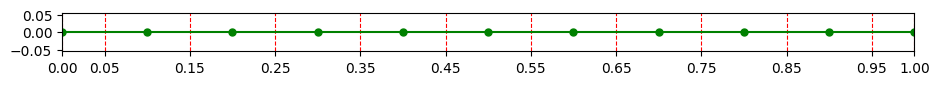

In [2]:
plt.figure(figsize=(11, 0.5))           ; lx=1.0 ;ly=0.1 ;lz=0.1 ;ncv=10                 ; grid = Grid(lx, ly, lz, ncv)               #  grid.xf (faces)  # grid.xP (centroid)
plt.xlim(grid.xf[0], grid.xf[10])       ; plt.plot  (grid.xf, np.zeros_like(grid.xf), 'o-', markersize=5,color='green')         ; print( grid.xf          , grid.xP)
plt.xticks(grid.xP)                     ; plt.grid(True, axis='x', linestyle='--', color='red')                                  

In [3]:
T0 = 300   ; T = T0*np.ones(grid.ncv+2)   ; T_solns = [np.copy(T)]     ; print('T',len(T),T)     ;maxIter = 100  ;coeffs = ScalarCoeffs(grid.ncv) ;converged = 1e-4
#______________init__(self,phi ,grid ,value ,loc) _________________________________________________________________________________________________________________
west_bc = DirichletBc(     T   ,grid ,400   ,BoundaryLocation.WEST)    ; west_bc.apply()         
east_bc = DirichletBc(T,grid,300,BoundaryLocation.EAST)                
east_bc = NeumannBc  (T, grid, 0, BoundaryLocation.EAST)               ; east_bc.apply()  

T 12 [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]


$ 
\quad\quad\quad      R_m = \frac{\sum_{i=0}^{N_{cv}-1} \left| r_{P,i} \right|}{N_{cv}} 
$   <font color='blue'> 
$   \quad\quad\quad      q = hA(T - T_\infty) \quad\quad\quad\quad\quad\quad $
a constant external convection term is added ______ based on Newton's law of cooling

In [4]:
# ____________________init__(self, grid ,phi ,gamma,west_bc ,east_bc):   ___________________________________________________________________________________________ 01a
k=100;  diffusion = DiffusionModel(grid ,T   ,k    ,west_bc ,east_bc)                            
# ____________________init________________________________(self, grid ,T ,ho ,To): _________________________________________________________________________________ 01b  
ho = 25 ; To = 200  ; surfaceConvection = SurfaceConvectionModel(grid ,T ,ho ,To)
for i in range(maxIter):
    coeffs.zero()             ;coeffs = diffusion.add(coeffs)  ;coeffs = surfaceConvection.add(coeffs)  ;maxResid = norm(coeffs.rP, np.inf) ;avgResid = np.mean(np.absolute(coeffs.rP))  
    print("Iteration = {}                                                                               ;Max. Resid. = {}                   ;Avg. Resid. = {}".format(i, maxResid, avgResid))
    if maxResid < converged:   break
    dT = solve(coeffs)        ;T[1:-1] += dT                   ;west_bc.apply();east_bc.apply();T_solns.append(np.copy(T))

Iteration = 0                                                                               ;Max. Resid. = 1900.0000000000005                   ;Avg. Resid. = 280.00000000000006
Iteration = 1                                                                               ;Max. Resid. = 7.105427357601002e-13                   ;Avg. Resid. = 3.520739255691296e-13


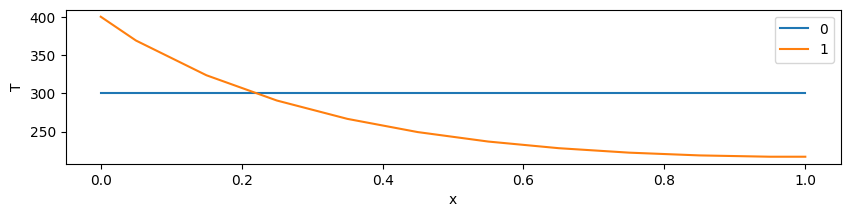

In [5]:
fig = plt.figure(figsize=(10, 2))                           ; i = 0
for T in T_solns:  plt.plot(grid.xP, T, label=str(i))  ;     i += 1
plt.xlabel("x") ;plt.ylabel("T") ;plt.legend() ;plt.show()

In [6]:
## _______________________ from Models import       DiffusionModel       SurfaceConvectionModel
class DiffusionModel:

    def __init__(self, grid, phi, gamma, west_bc, east_bc):
        self._grid = grid   ; self._phi = phi   ;self._gamma = gamma    ;self._west_bc = west_bc    ; self._east_bc = east_bc

    def add(self, coeffs):

        flux_w = - self._gamma*self._grid.Aw * (self._phi[1:-1]-self._phi[0:-2]) /self._grid.dx_WP
        flux_e = - self._gamma*self._grid.Ae * (self._phi[2:]  -self._phi[1:-1]) /self._grid.dx_PE      ; flux = flux_e - flux_w

        # Calculate the linearization coefficients
        coeffW = - self._gamma*self._grid.Aw / self._grid.dx_WP     
        coeffE = - self._gamma*self._grid.Ae / self._grid.dx_PE         ; coeffP = - coeffW - coeffE

        # Modify the linearization coefficients on the boundaries
        coeffP[0]  += coeffW[0]  * self._west_bc.coeff()    
        coeffP[-1] += coeffE[-1] * self._east_bc.coeff()
        # Zero the boundary coefficients that are not used
        coeffW[0] = 0.0 ; coeffE[-1] = 0.0
        # Add to coefficient arrays
        coeffs.accumulate_aP(coeffP) ; coeffs.accumulate_aW(coeffW) ; coeffs.accumulate_aE(coeffE)  ; coeffs.accumulate_rP(flux)

        return coeffs